Loading model and test data...
Test samples: 4600
Actual buyers in test set: 2263 / 4600

Running predictions...
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Won't buy       0.80      0.78      0.79      2337
    Will buy       0.77      0.80      0.79      2263

    accuracy                           0.79      4600
   macro avg       0.79      0.79      0.79      4600
weighted avg       0.79      0.79      0.79      4600

ROC-AUC Score : 0.8773
Rating        : Excellent ✅


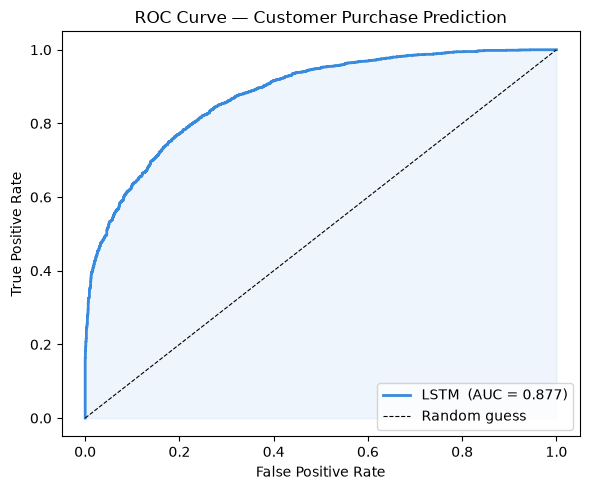


📊 roc_curve.png saved


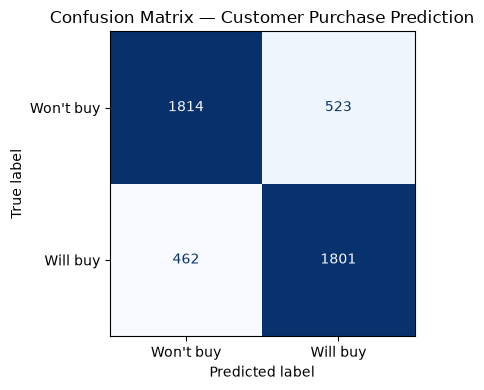

📊 confusion_matrix.png saved

         PLAIN ENGLISH SUMMARY
Total customers tested     : 4600
Correctly predicted buyers : 1801  (model said buy → actually bought)
Missed buyers              : 462  (model said no → actually bought)
False alarms               : 523  (model said buy → didn't buy)
Correctly predicted no-buy : 1814  (model said no → didn't buy)

Bottom line: model correctly identified 79.6% of all real buyers

✅ Evaluation complete — ready for Phase 5!


In [1]:
# evaluate.py

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ── 1. Load model and test data ──────────────────────────────
print("Loading model and test data...")
model  = load_model("lstm_model.h5")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print(f"Test samples: {len(X_test)}")
print(f"Actual buyers in test set: {y_test.sum()} / {len(y_test)}\n")

# ── 2. Get predictions ───────────────────────────────────────
print("Running predictions...")
y_pred_prob = model.predict(X_test, verbose=1).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# ── 3. Classification report ─────────────────────────────────
print("\n" + "=" * 50)
print("       CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=["Won't buy", "Will buy"]
))

# ── 4. ROC-AUC score ─────────────────────────────────────────
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {auc:.4f}")

if auc >= 0.85:
    print("Rating        : Excellent ✅")
elif auc >= 0.80:
    print("Rating        : Good ✅")
elif auc >= 0.70:
    print("Rating        : Acceptable ⚠️")
else:
    print("Rating        : Needs improvement ❌")

# ── 5. ROC curve chart ───────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#378ADD", linewidth=2,
         label=f"LSTM  (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random guess")
plt.fill_between(fpr, tpr, alpha=0.08, color="#378ADD")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Customer Purchase Prediction")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("\n📊 roc_curve.png saved")

# ── 6. Confusion matrix chart ────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Won't buy", "Will buy"]
)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(colorbar=False, cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix — Customer Purchase Prediction")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("📊 confusion_matrix.png saved")

# ── 7. Plain English summary ─────────────────────────────────
tn, fp, fn, tp = cm.ravel()
total = len(y_test)

print("\n" + "=" * 50)
print("         PLAIN ENGLISH SUMMARY")
print("=" * 50)
print(f"Total customers tested     : {total}")
print(f"Correctly predicted buyers : {tp}  (model said buy → actually bought)")
print(f"Missed buyers              : {fn}  (model said no → actually bought)")
print(f"False alarms               : {fp}  (model said buy → didn't buy)")
print(f"Correctly predicted no-buy : {tn}  (model said no → didn't buy)")
print(f"\nBottom line: model correctly identified "
      f"{tp/(tp+fn)*100:.1f}% of all real buyers")
print("=" * 50)
print("\n✅ Evaluation complete — ready for Phase 5!")